# Statistiques Word Structure sur le Direct S4 Gold : corrélations entre input et output

In [2]:
import re,codecs,yaml
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def ding():
    os.system('afplay /System/Library/Sounds/Submarine.aiff')

%store -r ordStemCells

In [3]:
sns.set_style("whitegrid")

In [4]:
repFiles="/Users/gilles/sDrive/Recherche/Boye/HDR/Data/vlexique2.0.3/WordStructure/"

# Étude Direct S4 Gold

In [5]:
cellOrd=['inf', 'pP', 'ppMS', 'ppMP', 'ppFS', 'ppFP', 'pi1S', 'pi2S', 'pi3S', 'pi1P', 'pi2P', 'pi3P', 'pI2S', 'pI1P', 'pI2P', 'ps1S', 'ps2S', 'ps3S', 'ps1P', 'ps2P', 'ps3P', 'ii1S', 'ii2S', 'ii3S', 'ii1P', 'ii2P', 'ii3P', 'fi1S', 'fi2S', 'fi3S', 'fi1P', 'fi2P', 'fi3P', 'pc1S', 'pc2S', 'pc3S', 'pc1P', 'pc2P', 'pc3P', 'ai1S', 'ai2S', 'ai3S', 'ai1P', 'ai2P', 'ai3P', 'is1S', 'is2S', 'is3S', 'is1P', 'is2P', 'is3P']

dColors={}
for c in cellOrd:
    if cellOrd.index(c)<21:
        dColors[c]="green"
    elif cellOrd.index(c)>38:
        dColors[c]="red"
    else:
        dColors[c]="orange"

cellColor=[dColors[c] for c in cellOrd]
cellGreen=[c for c,x in dColors.items() if x=="green"]
cellRed=[c for c,x in dColors.items() if x=="red"]
cellOrange=[c for c,x in dColors.items() if x=="orange"]

## Graphes Précision Rappel 

In [14]:
def getTable(fName):
    df=pd.read_csv(fName,sep=";")
    if "Unnamed: 0" in df.columns:
        df.set_index("Unnamed: 0",inplace=True)
        df.index.rename("lexeme",inplace=True)
    elif "lexeme" in df.columns:
        df.set_index("lexeme",inplace=True)
    for c in cellOrd:
        if c not in df.columns:
            df[c]=np.NaN
    return df[cellOrd]

In [ ]:
fInput4=repFiles+"vlexique2-S4.csv"
dfInput4=getTable(fInput4)
sInput4=dfInput4.count(axis=1)

fTest4=repFiles+"vlexique2-R4.csv"
dfTest4=getTable(fTest4)
sTest4=dfTest4.count(axis=1)

fDiff4=repFiles+"vlexique2-Direct-S4-omp-gold-different.csv"
fCorr4=repFiles+"vlexique2-Direct-S4-omp-gold-correct.csv"
fMiss4=repFiles+"vlexique2-Direct-S4-omp-gold-missing.csv"

dfDiff4=getTable(fDiff4)
sDiff4=dfDiff4.count(axis=1)
dfCorr4=getTable(fCorr4)
sCorr4=dfCorr4.count(axis=1)
dfMiss4=getTable(fMiss4)
sMiss4=dfMiss4.count(axis=1)

In [77]:
dfInput4.count(axis=1).mean()

12.608439415370109

# Corrélations

In [54]:
dfCorrel4=pd.DataFrame({"train":sInput4,"correct":sCorr4,"different":sDiff4,"missing":sMiss4})
dfCorrel4["test"]=dfCorrel4.correct+dfCorrel4.different+dfCorrel4.missing
dfCorrel4["recall"]=dfCorrel4.correct/dfCorrel4.test*100
dfCorrel4["precision"]=dfCorrel4.correct/(dfCorrel4.correct+dfCorrel4.different)*100
dfCorrel4["imprecision"]=dfCorrel4.different/(dfCorrel4.correct+dfCorrel4.different)*100

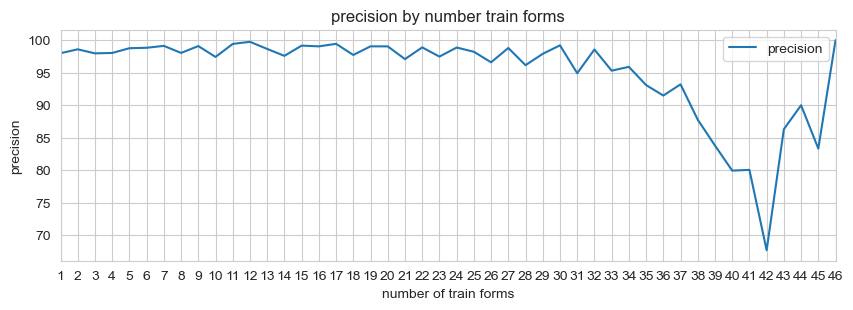

In [68]:
ylabel="precision"
ax=dfCorrel4[(dfCorrel4.test!=0)&(dfCorrel4.correct!=0)][["train",ylabel]].groupby("train").mean().plot(figsize=(10,3),title="%s by number train forms"%ylabel)
ax.set_xlabel("number of train forms")
ax.set_ylabel(ylabel)
ax.set_xticks(range(1,47))
ax.set_xlim([1,46])
plt.savefig(repFiles+"WS-Correlation-%s.png"%ylabel,dpi=300)

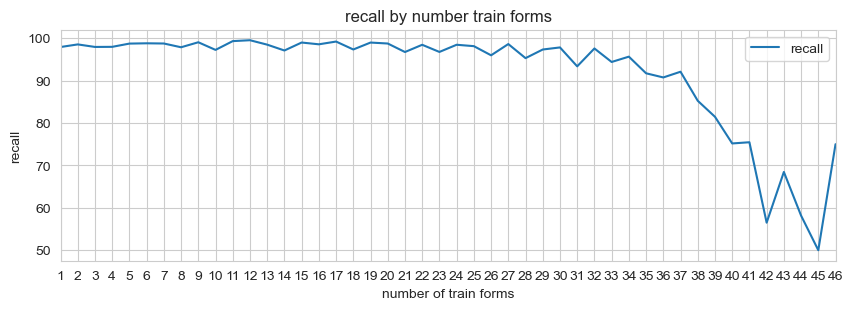

In [69]:
ylabel="recall"
ax=dfCorrel4[(dfCorrel4.test!=0)&(dfCorrel4.correct!=0)][["train",ylabel]].groupby("train").mean().plot(figsize=(10,3),title="%s by number train forms"%ylabel)
ax.set_xlabel("number of train forms")
ax.set_ylabel(ylabel)
ax.set_xticks(range(1,47))
ax.set_xlim([1,46])
plt.savefig(repFiles+"WS-Correlation-%s.png"%ylabel,dpi=300)

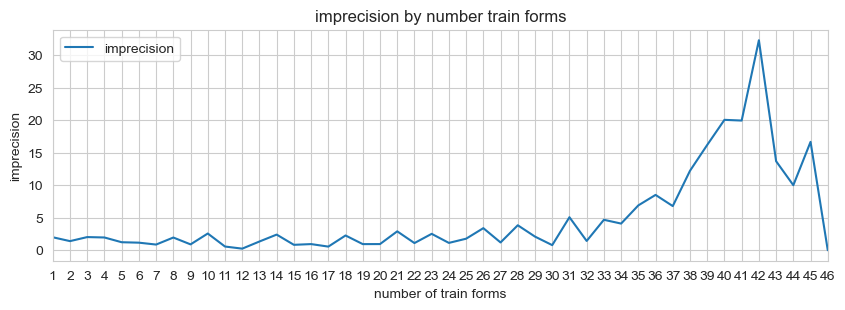

In [70]:
ylabel="imprecision"
ax=dfCorrel4[(dfCorrel4.test!=0)&(dfCorrel4.correct!=0)][["train",ylabel]].groupby("train").mean().plot(figsize=(10,3),title="%s by number train forms"%ylabel)
ax.set_xlabel("number of train forms")
ax.set_ylabel(ylabel)
ax.set_xticks(range(1,47))
ax.set_xlim([1,46])
plt.savefig(repFiles+"WS-Correlation-%s.png"%ylabel,dpi=300)

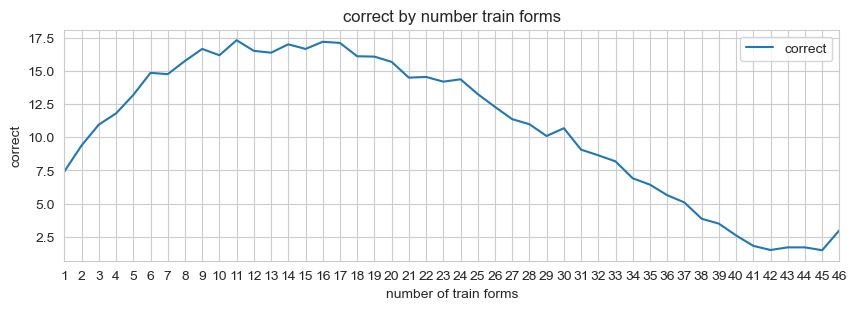

In [71]:
ylabel="correct"
ax=dfCorrel4[(dfCorrel4.test!=0)&(dfCorrel4.correct!=0)][["train",ylabel]].groupby("train").mean().plot(figsize=(10,3),title="%s by number train forms"%ylabel)
ax.set_xlabel("number of train forms")
ax.set_ylabel(ylabel)
ax.set_xticks(range(1,47))
ax.set_xlim([1,46])
plt.savefig(repFiles+"WS-Correlation-%s.png"%ylabel,dpi=300)

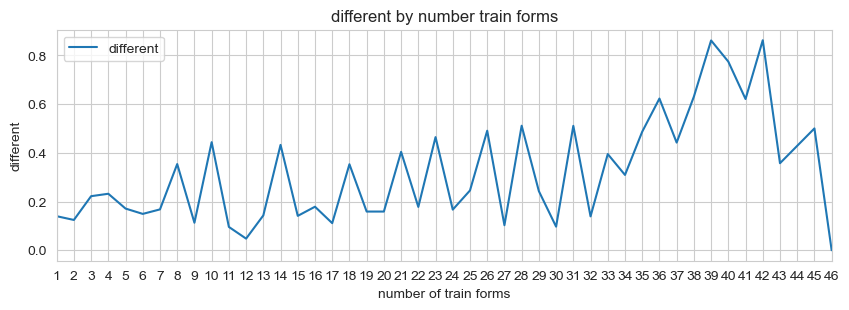

In [72]:
ylabel="different"
ax=dfCorrel4[(dfCorrel4.test!=0)&(dfCorrel4.correct!=0)][["train",ylabel]].groupby("train").mean().plot(figsize=(10,3),title="%s by number train forms"%ylabel)
ax.set_xlabel("number of train forms")
ax.set_ylabel(ylabel)
ax.set_xticks(range(1,47))
ax.set_xlim([1,46])
plt.savefig(repFiles+"WS-Correlation-%s.png"%ylabel,dpi=300)

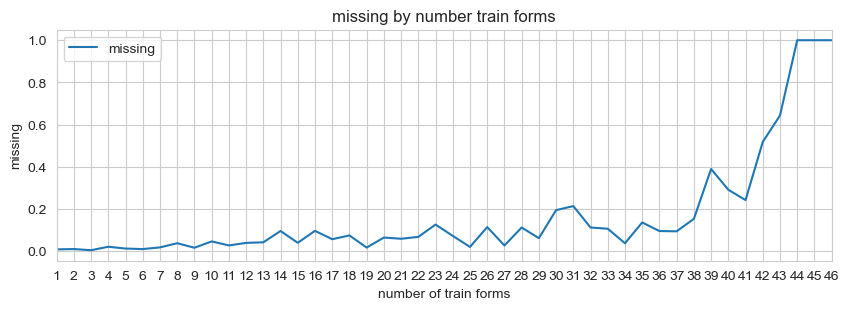

In [73]:
ylabel="missing"
ax=dfCorrel4[(dfCorrel4.test!=0)&(dfCorrel4.correct!=0)][["train",ylabel]].groupby("train").mean().plot(figsize=(10,3),title="%s by number train forms"%ylabel)
ax.set_xlabel("number of train forms")
ax.set_ylabel(ylabel)
ax.set_xticks(range(1,47))
ax.set_xlim([1,46])
plt.savefig(repFiles+"WS-Correlation-%s.png"%ylabel,dpi=300)